# Q-learning replicator dynamics

Companion code for Part I of the lecture on basins of attraction in multiagent reinforcement learning of the Summer School on Modern Methods in Reinforcement Learning.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Use Computer Modern-style math fonts
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'


def q_field(A, B, x, y, alpha=1.0, tau=1.0):
    """
    Compute the Q-learning vector field at (x, y).

    Parameters
    ----------
    A, B : 2x2 payoff matrices
    x, y : strategy probabilities
    alpha : learning rate
    tau : inverse temperature parameter
    """

    x_vec = np.array([x, 1 - x], dtype=float)
    y_vec = np.array([y, 1 - y], dtype=float)

    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    # Expected payoffs
    row_payoff = A @ y_vec
    col_payoff = B.T @ x_vec

    dx = alpha * x * (1 - x) * (
        tau * (row_payoff[0] - row_payoff[1])
        + np.log((1 - x) / x)
    )

    dy = alpha * y * (1 - y) * (
        tau * (col_payoff[0] - col_payoff[1])
        + np.log((1 - y) / y)
    )

    return np.array([dx, dy])


def normalized_field(U, V):
    norm = np.sqrt(U**2 + V**2 + 1e-12)
    return U / norm, V / norm


def direction_plot(A, B,
                   tau=1.0,
                   alpha=1.0,
                   eps=1e-3,
                   vector_points=15,
                   ax=None):

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))

    xs = np.linspace(eps, 1 - eps, vector_points)
    ys = np.linspace(eps, 1 - eps, vector_points)

    X, Y = np.meshgrid(xs, ys)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            U[i, j], V[i, j] = q_field(
                A, B,
                X[i, j],
                Y[i, j],
                alpha=alpha,
                tau=tau
            )

    U, V = normalized_field(U, V)

    ax.quiver(
        X, Y,
        U, V,
        color='black',
        pivot='mid'
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(r'$x$', fontsize=12)
    ax.set_ylabel(r'$y$', fontsize=12)

    ax.set_title(rf'$\tau = {tau}$', fontsize=13)

    return ax


def figure_direction_plots(A, B,
                           tau_list=(1, 2, 10),
                           alpha=1.0):

    fig, axes = plt.subplots(
        1,
        len(tau_list),
        figsize=(4 * len(tau_list), 4)
    )

    axes = np.atleast_1d(axes)

    for ax, tau in zip(axes, tau_list):
        direction_plot(
            A,
            B,
            tau=tau,
            alpha=alpha,
            ax=ax
        )

    plt.tight_layout()
    return fig

def q_learning_ode(t, z, A, B, alpha=1.0, tau=1.0):
    x, y = z

    # avoid numerical issues near boundaries
    eps = 1e-10
    x = np.clip(x, eps, 1 - eps)
    y = np.clip(y, eps, 1 - eps)

    dx, dy = q_field(
        A, B,
        x, y,
        alpha=alpha,
        tau=tau
    )

    return [dx, dy]

def compute_trajectory(
    x0,
    y0,
    A,
    B,
    tau=1.0,
    alpha=1.0,
    t_max=50,
    n_points=1000
):
    t_eval = np.linspace(0, t_max, n_points)

    sol = solve_ivp(
        q_learning_ode,
        [0, t_max],
        [x0, y0],
        args=(A, B, alpha, tau),
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-8
    )

    return sol.y[0], sol.y[1]

def plot_trajectory(
    x0,
    y0,
    A,
    B,
    tau=1.0,
    alpha=1.0,
    t_max=50,
    ax=None
):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))

    X, Y = compute_trajectory(
        x0,
        y0,
        A,
        B,
        tau=tau,
        alpha=alpha,
        t_max=t_max
    )

    ax.plot(X, Y, lw=2)
    ax.plot(X[0], Y[0], 'go', label='start')
    ax.plot(X[-1], Y[-1], 'ro', label='end')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    return ax

def direction_plot_with_trajectories(
    A,
    B,
    initial_conditions,
    tau=1.0,
    alpha=1.0,
    t_max=50
):
    fig, ax = plt.subplots(figsize=(6, 6))

    direction_plot(
        A,
        B,
        tau=tau,
        alpha=alpha,
        ax=ax
    )

    for x0, y0 in initial_conditions:

        X, Y = compute_trajectory(
            x0,
            y0,
            A,
            B,
            tau=tau,
            alpha=alpha,
            t_max=t_max
        )

        ax.plot(X, Y, lw=2)
        ax.plot(X[0], Y[0], 'ko', ms=4)

    return fig

Below is an example where we plot the vector field of the resulting dynamical system for different values of $\tau$ using payoff matrices corresponding to a prisoner's dilemma.

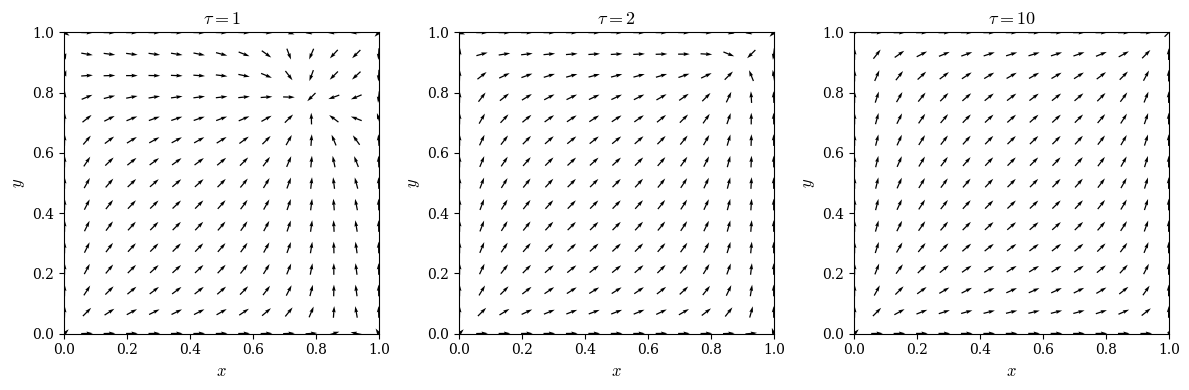

In [35]:
# Example
A = np.array([
    [1, 5],
    [0, 3]
])

B = np.array([
    [1, 0],
    [5, 3]
])

figure_direction_plots(
    A,
    B,
    tau_list=[1, 2, 10],
    alpha=1
)

plt.show()

Next we plot trajectories from initial conditions that we specfify on a single vector field plot.

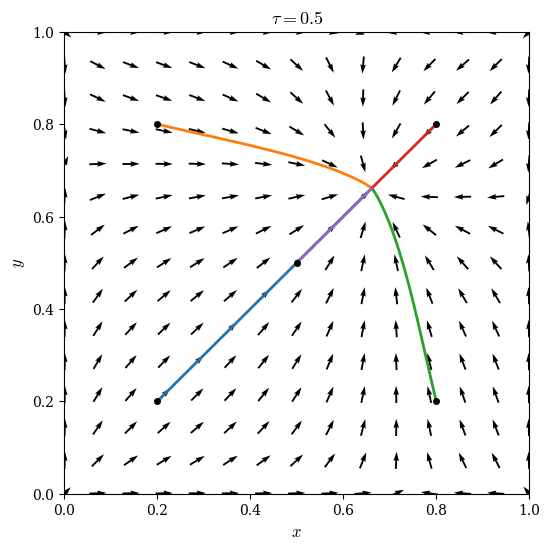

In [39]:
A = np.array([
    [1, 5],
    [0, 3]
])

B = np.array([
    [1, 0],
    [5, 3]
])

initial_conditions = [
    (0.2, 0.2),
    (0.2, 0.8),
    (0.8, 0.2),
    (0.8, 0.8),
    (0.5, 0.5)
]

direction_plot_with_trajectories(
    A,
    B,
    initial_conditions,
    tau=0.5
)

plt.show()

## Exercises 1

Consider the payoff matrices below and answer the following questions.

1. How many stationary points appear?
2. Which ones seem stable?
3. If the players start near $(0.8, 0.8)$ where will they converge to?
4. If the players start near $(0.2, 0.2)$ where will they converge to?

In [25]:
A = np.array([[4, 0],[0, 2]])
B = np.array([[4, 0],[0, 2]])

## Exercise 2

For the payoff matrices of the previous question simulate a collection of trajectories starting at a different initial conditions and color the trajectories according to which equilibrium they reach. What does the basin boundary look like?

## Exercise 3

Estimate the size of the basins of attraction.

1. Which equilibrium has the larger basin of attraction?
2. How does this change when varying $\tau$?